In [2]:
import torch, platform
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("cuDNN:", torch.backends.cudnn.version())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    # tiny cuda test
    x = torch.randn(1000,1000, device="cuda"); y = x @ x.T; print("OK:", y.is_cuda, y.shape)

Python: 3.10.10
Torch: 2.5.1+cu121
CUDA available: True
torch.version.cuda: 12.1
cuDNN: 90100
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
OK: True torch.Size([1000, 1000])


In [5]:
from pathlib import Path
import random, math
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch

# === PATHS ===
ROOT = Path(".")
DATA_DIR  = ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# === SEED + DEVICE ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")


Device in use: cuda


Scan dataset & splits

In [7]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".gif"}

def is_forged_folder(name: str) -> bool:
    return name.lower().endswith("_forg")

def list_images_with_labels_binary(root: Path):
    """Binary labels: 0=forged, 1=genuine (by folder name)."""
    paths, labels = [], []
    for person_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
        lab = 0 if is_forged_folder(person_dir.name) else 1
        for f in person_dir.rglob("*"):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(f)
                labels.append(lab)
    return paths, labels

def list_genuine_multiclass(root: Path):
    """For person-ID classification (multiclass): only genuine folders (no _forg)."""
    paths, person_ids = [], []
    for d in sorted([x for x in root.iterdir() if x.is_dir() and not is_forged_folder(x.name)]):
        pid = d.name  # class label is folder name
        for f in d.rglob("*"):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(f)
                person_ids.append(pid)
    return paths, person_ids

# Binary (forged vs genuine) scan — useful for quick checks
train_paths_bin, train_labels_bin = list_images_with_labels_binary(TRAIN_DIR)
test_paths_bin,  test_labels_bin  = list_images_with_labels_binary(TEST_DIR)

print("BINARY LABELS (0=forged, 1=genuine)")
print(f"Train images: {len(train_paths_bin)} | Test images: {len(test_paths_bin)}")
print("Train class distribution:", Counter(train_labels_bin))
print("Test  class distribution:", Counter(test_labels_bin))

# Multiclass (person ID) scan — this is what Q1 needs
tr_paths_mc, tr_pids = list_genuine_multiclass(TRAIN_DIR)
te_paths_mc, te_pids = list_genuine_multiclass(TEST_DIR)

all_pids = sorted(set(tr_pids))     # label space from TRAIN
pid2idx  = {p:i for i,p in enumerate(all_pids)}
idx2pid  = {i:p for p,i in pid2idx.items()}

y_tr_mc = [pid2idx[p] for p in tr_pids]
# filter test to only known (seen-in-train) person IDs
X_te_mc = [p for p,pid in zip(te_paths_mc, te_pids) if pid in pid2idx]
y_te_mc = [pid2idx[p] for p in te_pids if p in pid2idx]

print("\nMULTICLASS (person ID) — genuine only")
print(f"Train images: {len(tr_paths_mc)} | Test images (seen IDs only): {len(X_te_mc)}")
print(f"Num classes (persons): {len(all_pids)}")
print("Example class ids:", all_pids[:8])


BINARY LABELS (0=forged, 1=genuine)
Train images: 1649 | Test images: 500
Train class distribution: Counter({1: 887, 0: 762})
Test  class distribution: Counter({1: 252, 0: 248})

MULTICLASS (person ID) — genuine only
Train images: 887 | Test images (seen IDs only): 252
Num classes (persons): 64
Example class ids: ['001', '002', '003', '004', '006', '009', '012', '013']


Preview Random Samples

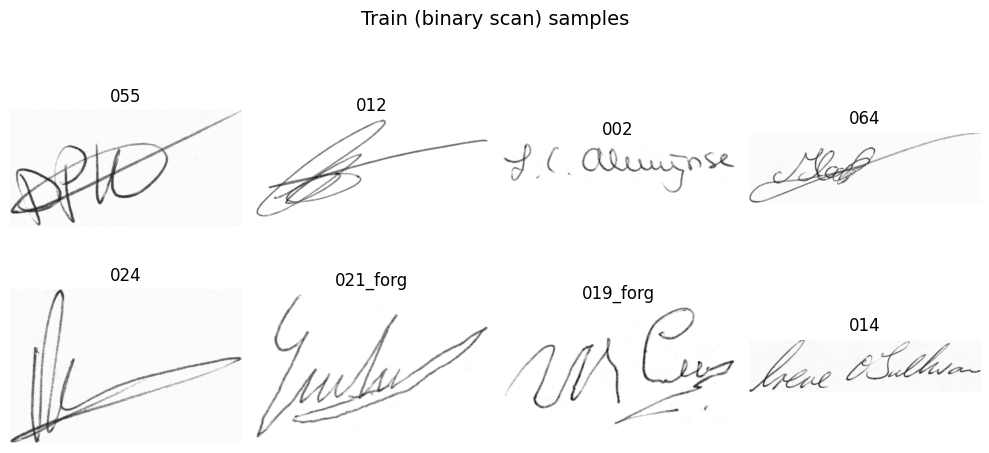

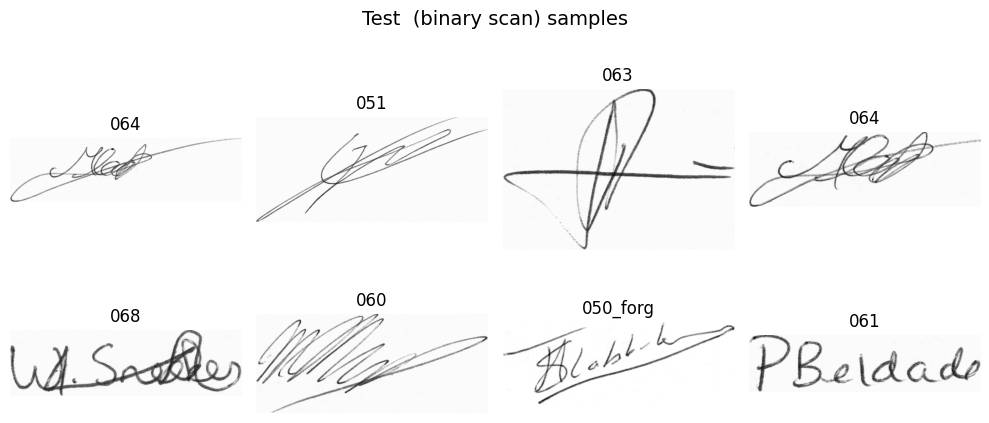

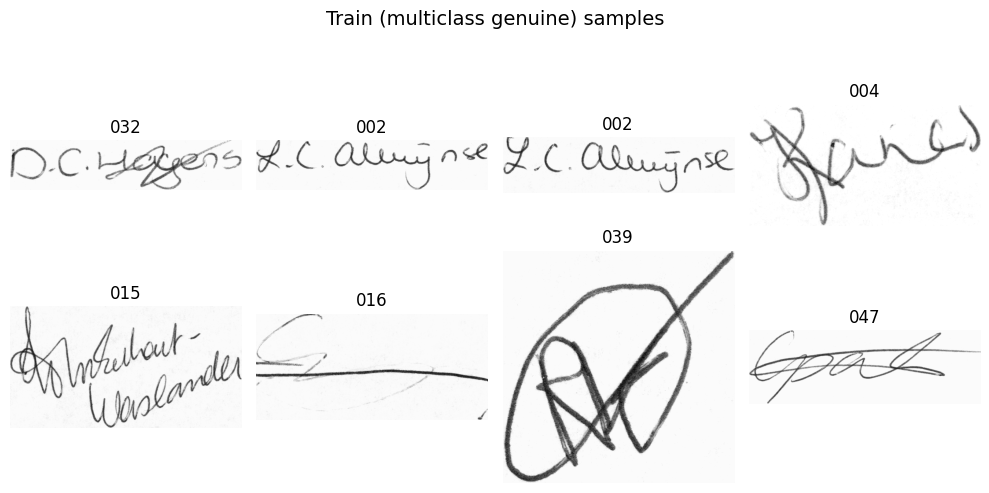

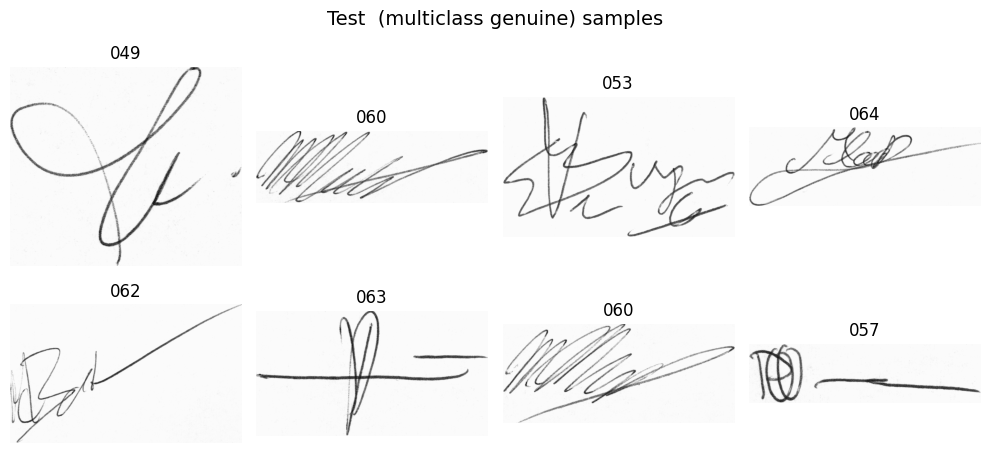

In [8]:
def show_grid(paths, n=8, title="samples"):
    cols = 4
    rows = math.ceil(n / cols)
    plt.figure(figsize=(10, 2.5 * rows))
    for i, p in enumerate(random.sample(paths, min(n, len(paths)))):
        im = Image.open(p).convert("L")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(im, cmap="gray")
        plt.axis("off")
        plt.title(p.parent.name)
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Preview binary-set images (mix of forged/genuine)
show_grid(train_paths_bin, 8, "Train (binary scan) samples")
show_grid(test_paths_bin,  8, "Test  (binary scan) samples")

# Preview multiclass genuine-only images (person ID)
show_grid(tr_paths_mc, 8, "Train (multiclass genuine) samples")
show_grid(X_te_mc,    8, "Test  (multiclass genuine) samples")


Integrity Checks (missing/corrupted files)

In [9]:
# Missing file checks
missing_train = [str(p) for p in train_paths_bin if not p.exists()]
missing_test  = [str(p) for p in test_paths_bin if not p.exists()]
print(f"Missing train files: {len(missing_train)}")
print(f"Missing test  files: {len(missing_test)}")

# Try opening a few to catch unreadable files
bad_files = []
for p in random.sample(train_paths_bin, min(50, len(train_paths_bin))):
    try:
        _ = Image.open(p).convert("L")
    except Exception as e:
        bad_files.append((str(p), repr(e)))

print(f"Unreadable images (sampled): {len(bad_files)}")
if bad_files:
    print("Examples:", bad_files[:3])


Missing train files: 0
Missing test  files: 0
Unreadable images (sampled): 0


Summary

In [10]:
print("==========================================")
print(" DATASET SUMMARY")
print("==========================================")
print("BINARY (forged vs genuine):")
print(f"  Train: {len(train_paths_bin)} | Test: {len(test_paths_bin)}")
print(f"  Train distribution: {Counter(train_labels_bin)}")
print(f"  Test  distribution: {Counter(test_labels_bin)}\n")

print("MULTICLASS (person ID; genuine only):")
print(f"  Train: {len(tr_paths_mc)} | Test(seen IDs): {len(X_te_mc)}")
print(f"  Num classes: {len(set(tr_pids))}")
print(f"  First few class ids: {sorted(set(tr_pids))[:10]}\n")

print(f"Device available : {device}")
print("Images verified  : previews displayed above")
print("==========================================")


 DATASET SUMMARY
BINARY (forged vs genuine):
  Train: 1649 | Test: 500
  Train distribution: Counter({1: 887, 0: 762})
  Test  distribution: Counter({1: 252, 0: 248})

MULTICLASS (person ID; genuine only):
  Train: 887 | Test(seen IDs): 252
  Num classes: 64
  First few class ids: ['001', '002', '003', '004', '006', '009', '012', '013', '014', '015']

Device available : cuda
Images verified  : previews displayed above
